# Gradient Descent

```bash
🎯 Goal
We will:

Create a simple dataset
Implement:
    Batch GD
    Stochastic GD (SGD)
    Mini-batch GD
Compare how they learn

```

🧪 1. Setup Dataset

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create synthetic data
np.random.seed(42)

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term (x0 = 1)
X_b = np.c_[np.ones((100, 1)), X]

⚙️ 2. Common Settings

In [7]:
learning_rate = 0.1
n_iterations = 50
m = len(X_b)

# 🔵 3. Batch Gradient Descent

👉 Uses entire dataset per update

In [8]:
theta_batch = np.random.randn(2, 1)

batch_costs = []

for iteration in range(n_iterations):
    gradients = (2/m) * X_b.T @ (X_b @ theta_batch - y)
    theta_batch = theta_batch - learning_rate * gradients
    
    cost = np.mean((X_b @ theta_batch - y) ** 2)
    batch_costs.append(cost)

print("Batch GD Theta:", theta_batch)

Batch GD Theta: [[3.91125197]
 [3.03839129]]


# 🔴 4. Stochastic Gradient Descent (SGD)

👉 Updates for every single data point

In [9]:
theta_mini = np.random.randn(2, 1)

mini_batch_size = 20
mini_costs = []

for iteration in range(n_iterations):
    shuffled_indices = np.random.permutation(m)
    X_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    
    for i in range(0, m, mini_batch_size):
        xi = X_shuffled[i:i+mini_batch_size]
        yi = y_shuffled[i:i+mini_batch_size]
        
        gradients = (2/len(xi)) * xi.T @ (xi @ theta_mini - yi)
        theta_mini = theta_mini - learning_rate * gradients

    cost = np.mean((X_b @ theta_mini - y) ** 2)
    mini_costs.append(cost)

print("Mini-Batch GD Theta:", theta_mini)

Mini-Batch GD Theta: [[4.22179151]
 [2.77014428]]


# 🟡 5. Mini-Batch Gradient Descent

👉 Updates using small chunks of data

In [10]:
theta_mini = np.random.randn(2, 1)

mini_batch_size = 20
mini_costs = []

for iteration in range(n_iterations):
    shuffled_indices = np.random.permutation(m)
    X_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    
    for i in range(0, m, mini_batch_size):
        xi = X_shuffled[i:i+mini_batch_size]
        yi = y_shuffled[i:i+mini_batch_size]
        
        gradients = (2/len(xi)) * xi.T @ (xi @ theta_mini - yi)
        theta_mini = theta_mini - learning_rate * gradients

    cost = np.mean((X_b @ theta_mini - y) ** 2)
    mini_costs.append(cost)

print("Mini-Batch GD Theta:", theta_mini)

Mini-Batch GD Theta: [[4.20479835]
 [2.76312115]]


# 📊 6. Compare Convergence

NameError: name 'sgd_costs' is not defined

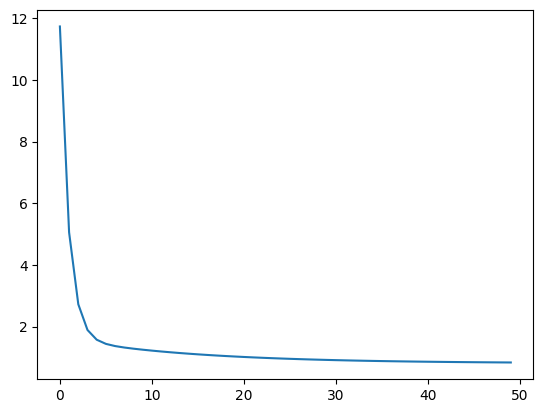

In [ ]:
plt.plot(batch_costs, label="Batch GD")
plt.plot(sgd_costs, label="SGD")
plt.plot(mini_costs, label="Mini-batch GD")

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")

plt.title("Gradient Descent Comparison")
plt.legend()
plt.show()